In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For better visuals
sns.set(style="whitegrid")

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving customer_behavior.csv).zip to customer_behavior.csv) (2).zip


In [ ]:
df = pd.read_csv("customer_behavior.csv).zip")
df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,46251,2020-09-08 09:38:32,Electronics,12,3,740,Credit Card,37,0.0,Christine Hernandez,37,Male,0
1,46251,2022-03-05 12:56:35,Home,468,4,2739,PayPal,37,0.0,Christine Hernandez,37,Male,0
2,46251,2022-05-23 18:18:01,Home,288,2,3196,PayPal,37,0.0,Christine Hernandez,37,Male,0
3,46251,2020-11-12 13:13:29,Clothing,196,1,3509,PayPal,37,0.0,Christine Hernandez,37,Male,0
4,13593,2020-11-27 17:55:11,Home,449,1,3452,Credit Card,49,0.0,James Grant,49,Female,1


In [ ]:
# Structure of dataset
df.info()

# Statistical summary
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  object 
 2   Product Category       250000 non-null  object 
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  object 
 7   Customer Age           250000 non-null  int64  
 8   Returns                202404 non-null  float64
 9   Customer Name          250000 non-null  object 
 10  Age                    250000 non-null  int64  
 11  Gender                 250000 non-null  object 
 12  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 24.8+ MB


,Customer ID,Product Price,Quantity,Total Purchase Amount,Customer Age,Returns,Age,Churn
count,250000.00000,250000.000000,250000.000000,250000.000000,250000.000000,202404.000000,250000.000000,250000.000000
mean,25004.03624,254.659512,2.998896,2725.370732,43.940528,0.497861,43.940528,0.199496
std,14428.27959,141.568577,1.414694,1442.933565,15.350246,0.499997,15.350246,0.399622
min,1.00000,10.000000,1.000000,100.000000,18.000000,0.000000,18.000000,0.000000
25%,12497.75000,132.000000,2.000000,1477.000000,31.000000,0.000000,31.000000,0.000000
50%,25018.00000,255.000000,3.000000,2724.000000,44.000000,0.000000,44.000000,0.000000
75%,37506.00000,377.000000,4.000000,3974.000000,57.000000,1.000000,57.000000,0.000000
max,50000.00000,500.000000,5.000000,5350.000000,70.000000,1.000000,70.000000,1.000000


In [ ]:
df.isnull().sum()

,0
Customer ID,0
Purchase Date,0
Product Category,0
Product Price,0
Quantity,0
Total Purchase Amount,0
Payment Method,0
Customer Age,0
Returns,47596
Customer Name,0


In [ ]:
df = df.dropna()

In [ ]:
df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])

In [ ]:
df['Month'] = df['Purchase Date'].dt.month
df['Year'] = df['Purchase Date'].dt.year

In [ ]:
total_revenue = df['Total Purchase Amount'].sum()
print("Total Revenue:", total_revenue)

Total Revenue: 551577377


In [ ]:
total_orders = df.shape[0]
print("Total Orders:", total_orders)

Total Orders: 202404


In [ ]:
avg_order_value = df['Total Purchase Amount'].mean()
print("Average Order Value:", avg_order_value)

Average Order Value: 2725.1308126321615


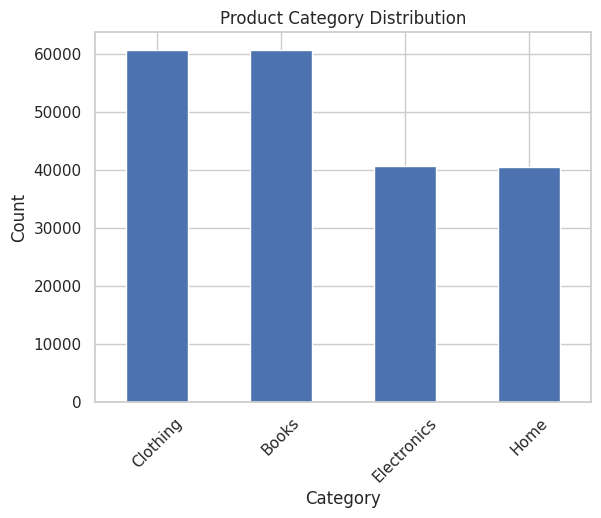

In [ ]:
plt.figure()
df['Product Category'].value_counts().plot(kind='bar')
plt.title("Product Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

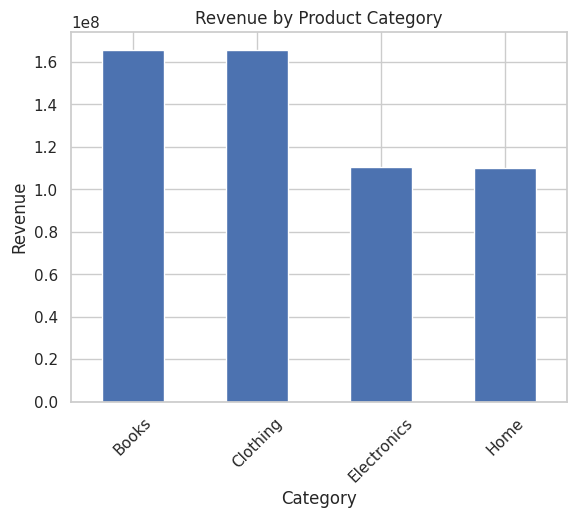

In [ ]:
plt.figure()
df.groupby('Product Category')['Total Purchase Amount'].sum().plot(kind='bar')
plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

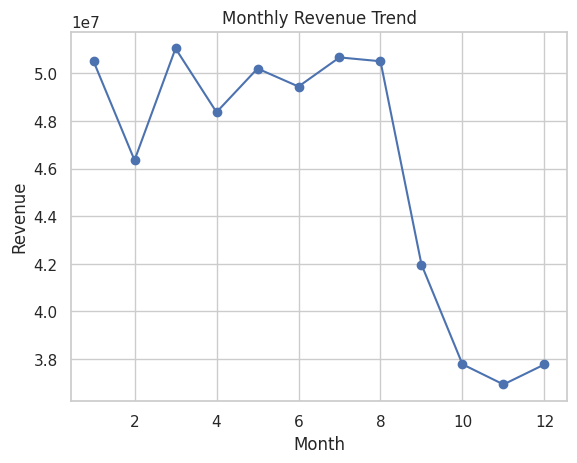

In [ ]:
monthly_sales = df.groupby('Month')['Total Purchase Amount'].sum()
plt.figure()
monthly_sales.plot(marker='o')
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

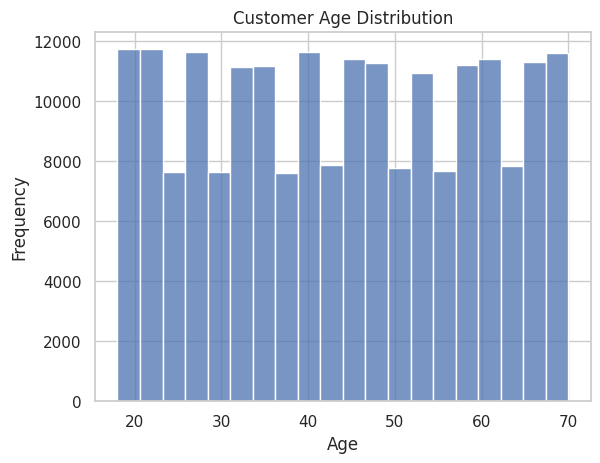

In [ ]:
plt.figure()
sns.histplot(df['Customer Age'], bins=20)
plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()


/tmp/ipykernel_22976/3534102414.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Age Group')['Total Purchase Amount'].sum().plot(kind='bar')


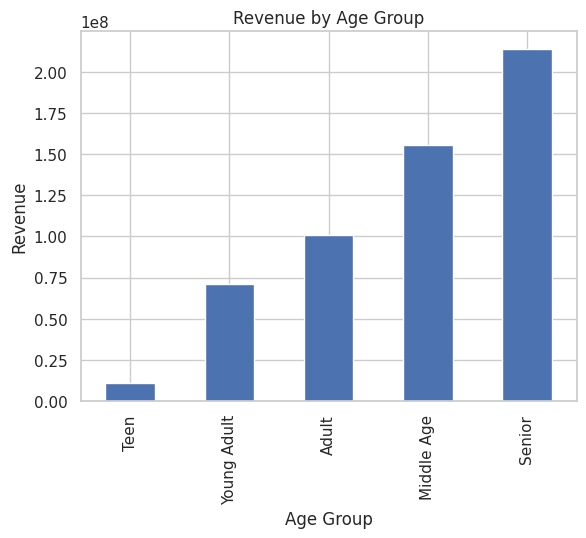

In [ ]:
df['Age Group'] = pd.cut(df['Customer Age'],
                        bins=[0,18,25,35,50,100],
                        labels=['Teen','Young Adult','Adult','Middle Age','Senior'])
plt.figure()
df.groupby('Age Group')['Total Purchase Amount'].sum().plot(kind='bar')
plt.title("Revenue by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Revenue")
plt.show()

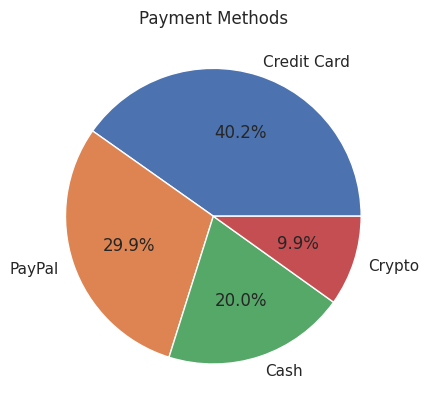

In [ ]:
plt.figure()
df['Payment Method'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Payment Methods")
plt.ylabel("")
plt.show()

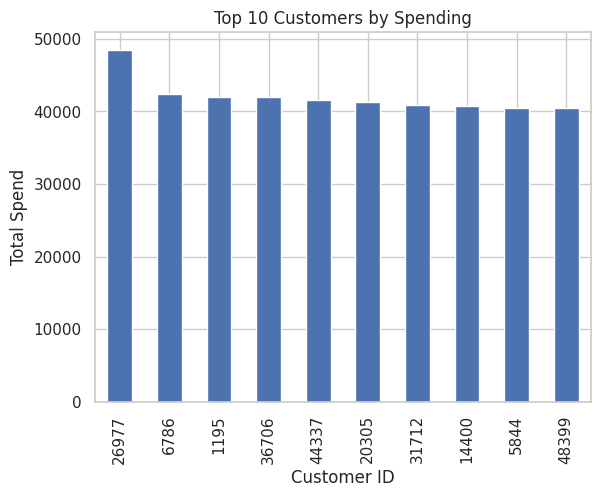

In [ ]:
top_customers = df.groupby('Customer ID')['Total Purchase Amount'].sum().sort_values(ascending=False).head(10)

plt.figure()
top_customers.plot(kind='bar')
plt.title("Top 10 Customers by Spending")
plt.xlabel("Customer ID")
plt.ylabel("Total Spend")
plt.show()

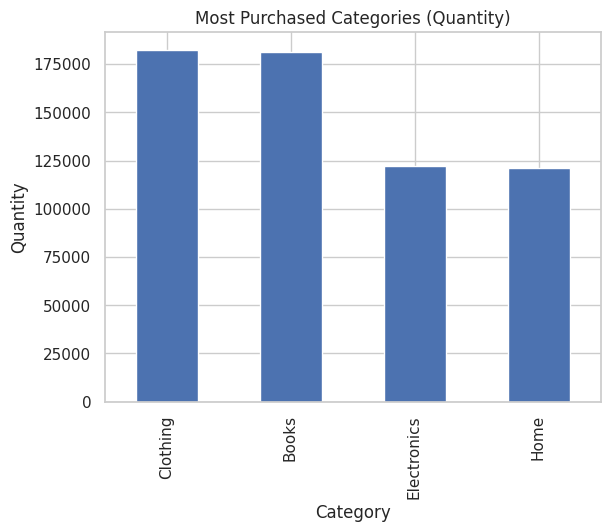

In [ ]:
plt.figure()
df.groupby('Product Category')['Quantity'].sum().sort_values(ascending=False).plot(kind='bar')
plt.title("Most Purchased Categories (Quantity)")
plt.xlabel("Category")
plt.ylabel("Quantity")
plt.show()

In [ ]:
avg_spend_age = df.groupby('Age Group')['Total Purchase Amount'].mean()
print(avg_spend_age)

Age Group
Teen           2619.515129
Young Adult    2623.428915
Adult          2653.701060
Middle Age     2715.680340
Senior         2809.651567
Name: Total Purchase Amount, dtype: float64


/tmp/ipykernel_22976/505778579.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_spend_age = df.groupby('Age Group')['Total Purchase Amount'].mean()


In [ ]:
df.to_csv("cleaned_customer_data.csv", index=False)